In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import RandomOverSampler





In [23]:
df = pd.read_csv(r'C:\Users\Admin\Downloads\creditcard.csv.zip')   # Update path if needed
print(df.shape)        # How many rows and columns?
print(df.head())       # Preview the first 5 rows
print(df['Class'].value_counts())   # How many fraud vs. not fraud?

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

C:\Users\Admin\AppData\Local\Temp\ipykernel_16988\3740648687.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue','red'])


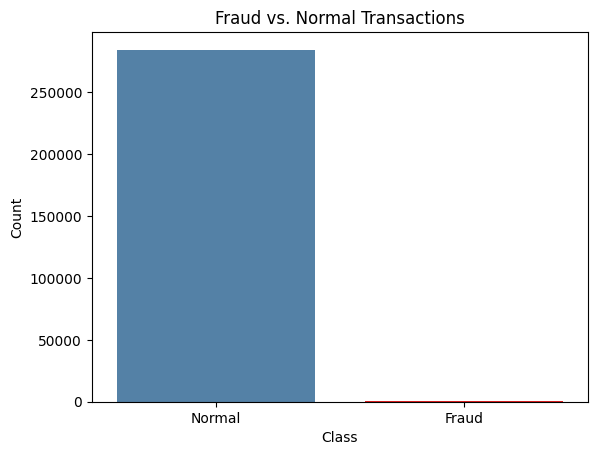

In [24]:
sns.countplot(x='Class', data=df, palette=['steelblue','red'])
plt.title('Fraud vs. Normal Transactions')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.show()

In [25]:
X = df.drop('Class', axis=1)   # Everything except the 'Class' column
y = df['Class']                 # Just the 'Class' column (fraud or not)

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print('After resampling:')
print(pd.Series(y_train_res).value_counts())

After resampling:
Class
0    227451
1    227451
Name: count, dtype: int64


In [26]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [27]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
lr_preds = lr.predict(X_test)


In [28]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test)


In [29]:
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=['Normal','Fraud']))
print('ROC-AUC Score:', roc_auc_score(y_test, lr_preds))


=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9470230797721452


In [30]:
print('=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=['Normal','Fraud']))
print('ROC-AUC Score:', roc_auc_score(y_test, rf_preds))


=== Random Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.49      0.86      0.62        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9278064454538146


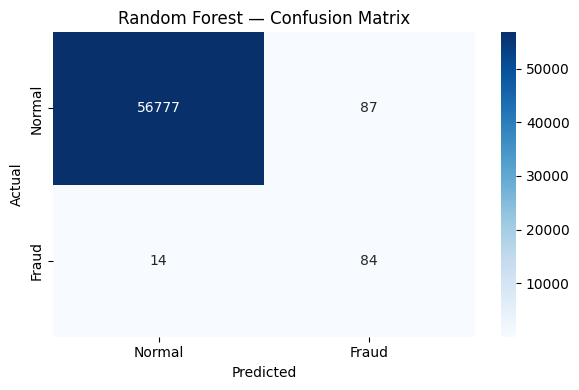

In [31]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_16988\3641697488.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


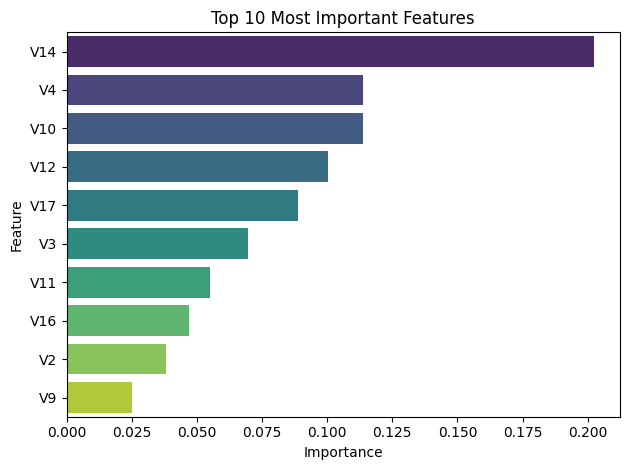

In [32]:
importances = rf.feature_importances_
feat_names = df.drop('Class', axis=1).columns
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()
